In [3]:
%pip install pandas matplotlib seaborn

  Using cached pandas-3.0.6-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.2-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.5.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.0-cp313-cp313-win_amd64.whl.metadata (131 kB)
  Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached pandas-3.0.6-cp313-cp313-win_amd64.whl (9.6 MB)
Using cached matplotlib-3.11.2-cp313-cp313-win_amd64.whl (9.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.4.0-cp313-cp3


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


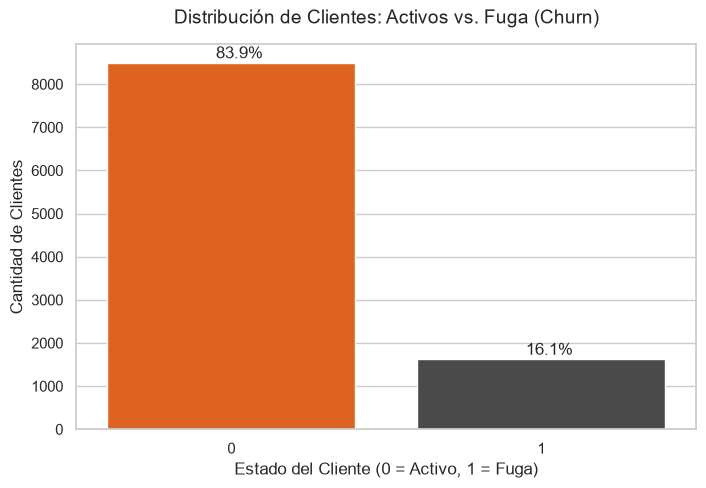

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset procesado
df = pd.read_csv('../data/processed/naranjax_churn_dataset.csv')

# 2. Configurar el estilo visual (colores de Naranja X)
sns.set_theme(style="whitegrid")
naranja_x_colors = ["#FF5A00", "#4A4A4A"] # Naranja para clientes activos, Gris para Churn

# 3. Crear el gráfico de distribución del Target
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Churn', hue='Churn', palette=naranja_x_colors, legend=False)

# 4. Ajustes estéticos
plt.title('Distribución de Clientes: Activos vs. Fuga (Churn)', fontsize=14, pad=15)
plt.xlabel('Estado del Cliente (0 = Activo, 1 = Fuga)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# 5. Agregar los porcentajes arriba de las barras
total = len(df)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 100
    ax.annotate(porcentaje, (x, y), size=12)

plt.show()

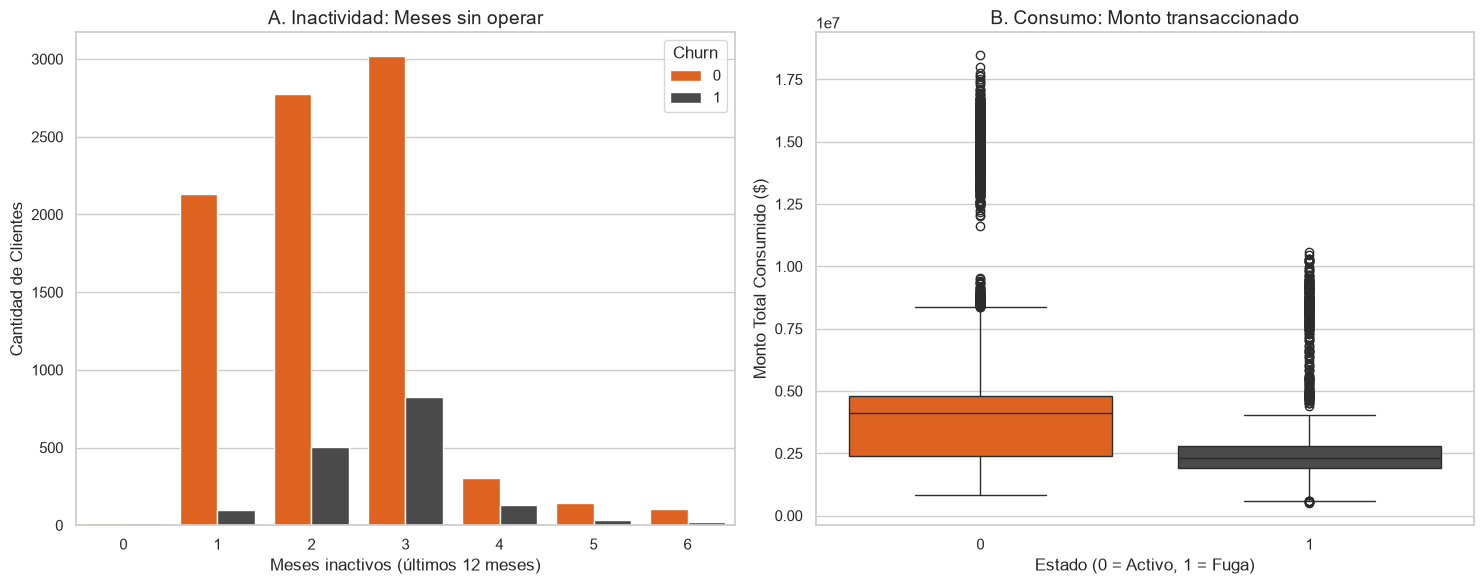

In [7]:
# 1. Configurar un panel con 2 gráficos a la par
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico A: ¿La inactividad predice el abandono? (Countplot)
sns.countplot(data=df, x='Months_Inactive_12_mon', hue='Churn', palette=naranja_x_colors, ax=axes[0])
axes[0].set_title('A. Inactividad: Meses sin operar', fontsize=14)
axes[0].set_xlabel('Meses inactivos (últimos 12 meses)', fontsize=12)
axes[0].set_ylabel('Cantidad de Clientes', fontsize=12)

# Gráfico B: ¿Gastan menos los que terminan yéndose? (Boxplot)
# Usamos hue='Churn' y legend=False para evitar el FutureWarning de Seaborn
sns.boxplot(data=df, x='Churn', y='Total_Trans_Amt', hue='Churn', palette=naranja_x_colors, legend=False, ax=axes[1])
axes[1].set_title('B. Consumo: Monto transaccionado', fontsize=14)
axes[1].set_xlabel('Estado (0 = Activo, 1 = Fuga)', fontsize=12)
axes[1].set_ylabel('Monto Total Consumido ($)', fontsize=12)

plt.tight_layout()
plt.show()

Conclusiones clave del análisis:

Gráfico A (Inactividad): A partir del tercer mes sin operar, la proporción de fuga (Churn) aumenta drásticamente, llegando a representar casi un tercio de los clientes en ese segmento.

Gráfico B (Consumo): Existe una clara sinergia entre el abandono y el nivel de gasto. Los clientes que terminan dándose de baja muestran un volumen de transacciones significativamente menor que los clientes activos.

Impacto de Negocio: La caída en el consumo y la inactividad son señales de alerta temprana. Naranja X debería detonar acciones de retención (promociones o incentivos personalizados) antes de que el cliente alcance su tercer mes de inactividad, momento en el cual el riesgo de fuga se dispara.